<a href="https://colab.research.google.com/github/tusharsingh3199/ML-Projects/blob/main/BrainTumorSegemtation/BraTS_Exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
# Colab Specifics
from google.colab import drive, userdata

# Standard & Utilities
import os, random
from collections import defaultdict
from tqdm import tqdm
import zipfile

# Data Science & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from ipywidgets import interact, IntSlider

# Medical Imaging & ML
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

"""
Time for Training:

1. 2D Model = 6-7 hrs for 1 epoch.
2. 3D Model = 1 hr for 1 epoch.

"""


In [146]:
# Install the latest Kaggle tool (as required by the new tokens)
!pip install -U kaggle
!kaggle datasets download --d aryashah2k/brain-tumor-segmentation-brats-2019

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/brain-tumor-segmentation-brats-2019
License(s): CC0-1.0
brain-tumor-segmentation-brats-2019.zip: Skipping, found more recently modified local copy (use --force to force download)


In [147]:
drive.mount('/content/drive')
source_file = "/content/brain-tumor-segmentation-brats-2019.zip"

tutorial_data_path = "/content/MICCAI_BraTS_2019_Data_Training"
dataset_path = "/content/MICCAI_BraTS_2019_Data_Training"
destination_folder = "/content/MICCAI_BraTS_2019_Data_Training"

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 1. Create the destination folder if it doesn't exist
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
    with zipfile.ZipFile(source_file, 'r') as zip_ref:
        zip_ref.extractall()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [148]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def random_patient_path(base_dir, grade):
    grade_dir = os.path.join(base_dir, grade)
    patients = sorted(os.listdir(grade_dir))
    patient = random.choice(patients)
    return os.path.join(grade_dir, patient), patient

def load_brats_case(patient_dir, modality="flair"):
    files = os.listdir(patient_dir)

    #img_file = [f for f in files if modality in f.lower()][0]
    img_file = [f for f in files if f.lower().endswith(f"_{modality.lower()}.nii")][0]
    seg_file = [f for f in files if "seg" in f.lower()][0]

    img = nib.load(os.path.join(patient_dir, img_file)).get_fdata()
    seg = nib.load(os.path.join(patient_dir, seg_file)).get_fdata()

    return img, seg

def normalize_to_uint8(volume):
    v = volume.copy()
    v = (v - v.min()) / (v.max() - v.min() + 1e-8)
    v = (v * 255).astype(np.uint8)
    return v

def show_slices(volume, seg, title=""):
    """
    Slider-based visualization of axial slices with normalized intensity
    and a clean, masked segmentation overlay.
    """
    volume_vis = normalize_to_uint8(volume)
    max_slice = volume_vis.shape[2] - 1

    # BraTS label definitions
    label_info = {
        1: "Necrotic / Non-enhancing Tumor Core",
        2: "Peritumoral Edema",
        4: "Enhancing Tumor"
    }

    # Create legend patches
    legend_patches = [
        mpatches.Patch(color=plt.cm.jet(1/4), label=label_info[1]),
        mpatches.Patch(color=plt.cm.jet(2/4), label=label_info[2]),
        mpatches.Patch(color=plt.cm.jet(4/4), label=label_info[4]),
    ]

    def view_slice(z):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # 1. Original grayscale image
        axes[0].imshow(volume_vis[:, :, z], cmap="gray")
        axes[0].set_title(f"{title} - Image (slice {z})")
        axes[0].axis("off")

        # 2. Clean Overlay
        axes[1].imshow(volume_vis[:, :, z], cmap="gray")

        # --- The Fix: Masking the background (0s) ---
        slice_seg = seg[:, :, z]
        masked_seg = np.ma.masked_where(slice_seg == 0, slice_seg)

        # Plot the mask with vmin/vmax to keep colors consistent
        axes[1].imshow(masked_seg, cmap="jet", alpha=0.5, vmin=0, vmax=4)
        axes[1].set_title("Segmentation Overlay")
        axes[1].axis("off")

        # Add legend
        fig.legend(
            handles=legend_patches,
            loc="lower center",
            ncol=3,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.15, 1, 1])
        plt.show()

    interact(
        view_slice,
        z=IntSlider(min=0, max=max_slice, step=1, value=max_slice // 2)
    )


In [149]:
set_seed(42)
patient_dir = random_patient_path(destination_folder, "LGG")
lgg_img, lgg_seg = load_brats_case(patient_dir[0], modality="flair")
show_slices(lgg_img, lgg_seg, title=f"MRI Scan")


interactive(children=(IntSlider(value=77, description='z', max=154), Output()), _dom_classes=('widget-interact…

In [150]:
def collect_patient_data(base_dir, fraction=0.1):
    patient_data = [] # List of tuples: (path, label (HGG/LGG))

    for grade in ["HGG", "LGG"]:
        grade_dir = os.path.join(base_dir, grade)
        patients = sorted(os.listdir(grade_dir))
        patient_paths = [os.path.join(grade_dir, p) for p in patients]

        n_select = max(1, int(len(patients) * fraction))
        selected_paths = np.random.choice(patient_paths, n_select, replace=False)
        for path in selected_paths:
            patient_data.append((path, grade))

    return patient_data

patient_data = collect_patient_data(dataset_path, fraction=0.1)

train_data, temp_data = train_test_split( patient_data, test_size=0.25, random_state=42, stratify=[d[1] for d in patient_data])
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42, stratify=[d[1] for d in temp_data])

def load_nifti(path):
    return nib.load(path).get_fdata()

def normalize_volume(volume):
    mean = volume.mean()
    std = volume.std()
    if std == 0:
        return volume
    return (volume - mean) / std

def remap_labels(mask):
    """
    BraTS labels: {0, 1, 2, 4}
    Remapped to:  {0, 1, 2, 3}
    """
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask


In [151]:
class BraTS2019SliceDataset(Dataset):
    def __init__(self, patient_data_list):
        self.samples = []

        for patient_path, _ in patient_data_list:
            num_slices = 155
            for z in range(num_slices):
                self.samples.append((patient_path, z))

        self.cur_patient_path = None
        self.cur_volumes = None

    def _find_file(self, patient_path, keyword):
        files = os.listdir(patient_path)
        for f in files:
            # Adding "_" ensures 't1' doesn't match 't1ce'
            if f.lower().endswith(f"_{keyword.lower()}.nii") or f.lower().endswith(f"_{keyword.lower()}.nii.gz"):
                return os.path.join(patient_path, f)
        raise FileNotFoundError(f"Could not find {keyword} in {patient_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patient_path, z = self.samples[idx]

        if patient_path != self.cur_patient_path:
            self.cur_patient_path = patient_path
            self.cur_volumes = {
                "t1": normalize_volume(load_nifti(self._find_file(patient_path, "t1"))),
                "t1ce": normalize_volume(load_nifti(self._find_file(patient_path, "t1ce"))),
                "t2": normalize_volume(load_nifti(self._find_file(patient_path, "t2"))),
                "flair": normalize_volume(load_nifti(self._find_file(patient_path, "flair"))),
                "seg": remap_labels(load_nifti(self._find_file(patient_path, "seg")))
            }

        v = self.cur_volumes
        image = np.stack([v["t1"][:,:,z], v["t1ce"][:,:,z], v["t2"][:,:,z], v["flair"][:,:,z]], axis=0)
        mask = v["seg"][:,:,z]

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

train_dataset = BraTS2019SliceDataset(train_data)
val_dataset   = BraTS2019SliceDataset(val_data)
test_dataset  = BraTS2019SliceDataset(test_data)

batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(train_loader.dataset[0][0].shape)
print(train_loader.dataset[0][1].shape)

torch.Size([4, 240, 240])
torch.Size([240, 240])


In [152]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet2D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4):
        super().__init__()

        # -------- Encoder --------
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2)

        # -------- Bottleneck --------
        self.bottleneck = DoubleConv(512, 1024)

        # -------- Decoder --------
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # -------- Output --------
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

model = UNet2D(
    in_channels=4,   # T1, T1ce, T2, FLAIR
    num_classes=4    # background + tumor subregions
).to(device)

#print(model)

In [153]:
class DiceCELoss(nn.Module):
    def __init__(self, num_classes=4, smooth=1e-6):
        super(DiceCELoss, self).__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        # Cross Entropy is excellent for global class relations
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        """
        inputs: raw logits from model (B, C, H, W)
        targets: class indices (B, H, W)
        """
        # 1. Compute Cross Entropy Loss
        ce_loss = self.ce(inputs, targets)

        # 2. Compute Soft Dice Loss
        probs = F.softmax(inputs, dim=1)

        # We create the one-hot tensor and immediately move it to the
        # same device as the model inputs (CPU or GPU)
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        targets_one_hot = targets_one_hot.to(inputs.device)

        # Sum over Batch, Height, and Width
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)

        # Compute Dice Score and then Dice Loss (1 - Score)
        dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)
        dice_loss = 1 - torch.mean(dice_score)

        # 3. Hybrid Weighting (Note: A 50/50 weighting is a common and effective choice, but not universally optimal.)
        return 0.5 * ce_loss + 0.5 * dice_loss

criterion = DiceCELoss(num_classes=4)
learning_rate = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-5
)

num_epochs = 1

def train_unet(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    save_path
):
    best_val_loss = float('inf') # Added to track progress

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        #for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        for images, masks in pbar_train:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)          # (B, C, H, W)
            loss = criterion(outputs, masks) # masks: (B, H, W)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar_train.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0

        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        with torch.no_grad():
            #for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            for images, masks in pbar_val:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"--> Model improved! Saved to {save_path}")

        print(
            f"\n Epoch [{epoch+1}/{num_epochs}] "
            f"\n Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )


In [154]:
checkpoint_path_2d = os.path.join(tutorial_data_path, "best_model_2d.pth")

train_unet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device,
    save_path = checkpoint_path_2d
)


Epoch 1/1 [Val]: 100%|██████████| 155/155 [00:20<00:00,  7.65it/s]


--> Model improved! Saved to /content/MICCAI_BraTS_2019_Data_Training/best_model_2d.pth

 Epoch [1/1] 
 Train Loss: 0.5589 | Val Loss: 0.4005


In [155]:
def multiclass_dice(pred, target, num_classes=4, ignore_background=True):
    """
    pred, target: (H, W) tensors with class indices
    """
    dice_scores = {}
    classes = range(1, num_classes) if ignore_background else range(num_classes)

    for cls in classes:
        pred_c = (pred == cls).float()
        target_c = (target == cls).float()

        intersection = (pred_c * target_c).sum()
        denominator = pred_c.sum() + target_c.sum()

        if denominator == 0:
            dice = torch.tensor(float('nan'))
        else:
            dice = (2.0 * intersection) / (denominator + 1e-6)

        dice_scores[cls] = dice.item()

    return dice_scores

def evaluate_model(model, dataloader, device, num_classes=4):
    model.eval()

    dice_accumulator = {cls: [] for cls in range(1, num_classes)}

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)              # (B, C, H, W)
            preds = torch.argmax(outputs, dim=1) # (B, H, W)

            for b in range(preds.size(0)):
                dice_scores = multiclass_dice(
                    preds[b],
                    masks[b],
                    num_classes=num_classes,
                    ignore_background=True
                )

                for cls, score in dice_scores.items():
                    dice_accumulator[cls].append(score)

    # Compute mean Dice per class
    #mean_dice = {
    #    cls: sum(scores) / len(scores) if len(scores) > 0 else 0.0
    #    for cls, scores in dice_accumulator.items()
    #}

    #--- UPDATED AVERAGING LOGIC ---
    mean_dice = {}
    for cls, scores in dice_accumulator.items():
        # Filter out NaN values (empty slices)
        valid_scores = [s for s in scores if not np.isnan(s)]

        if len(valid_scores) > 0:
            mean_dice[cls] = sum(valid_scores) / len(valid_scores)
        else:
            # If a class was NEVER present in any slice (highly unlikely for BraTS)
            mean_dice[cls] = 0.0

    # Compute overall mean Dice
    overall_mean_dice = sum(mean_dice.values()) / len(mean_dice)

    return mean_dice, overall_mean_dice


mean_dice, overall_dice = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=device,
    num_classes=4
)

# Mapping to make the results more "clinical"
brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

print("Dice score per class (excluding background):")
for cls, score in mean_dice.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall Mean Dice (Across all tumor regions): {overall_dice:.4f}")

Dice score per class (excluding background):
  Necrotic / Non-enhancing Core (NCR/NET): 0.1899
  Edema (ED): 0.2613
  Enhancing Tumor (ET): 0.2962

Overall Mean Dice (Across all tumor regions): 0.2491


In [156]:
def volume_dice_per_patient(model, patient_dirs, device, num_classes=4):
    model.eval()

    # Store Dice scores per class for each patient
    patient_dice_scores = {cls: [] for cls in range(1, num_classes)}

    with torch.no_grad():
        for patient_dir in patient_dirs:

            # -------- Load modalities --------
            t1 = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "t1.nii" in f.lower()][0])
            ))
            t1ce = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "t1ce.nii" in f.lower()][0])
            ))
            t2 = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "t2.nii" in f.lower()][0])
            ))
            flair = normalize_volume(load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "flair.nii" in f.lower()][0])
            ))

            seg = load_nifti(
                os.path.join(patient_dir, [f for f in os.listdir(patient_dir) if "seg" in f.lower()][0])
            )
            seg = remap_labels(seg)

            # Stack modalities
            volume = np.stack([t1, t1ce, t2, flair], axis=0)  # (4, H, W, D)

            # -------- Predict full volume --------
            preds_volume = []

            for z in range(seg.shape[2]):
                slice_img = torch.tensor(
                    volume[:, :, :, z],
                    dtype=torch.float32
                ).unsqueeze(0).to(device)

                output = model(slice_img)
                pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
                preds_volume.append(pred)

            preds_volume = np.stack(preds_volume, axis=2)

            # -------- Compute Dice per class (volume-level) --------
            for cls in range(1, num_classes):

                pred_c = (preds_volume == cls)
                target_c = (seg == cls)

                intersection = (pred_c & target_c).sum()
                denominator = pred_c.sum() + target_c.sum()

                if denominator == 0:
                    #dice = 1.0
                    dice = np.nan
                else:
                    dice = (2.0 * intersection) / (denominator + 1e-6)

                patient_dice_scores[cls].append(dice)

    # -------- Average across patients --------
    #mean_dice = {
    #    cls: np.mean(scores) if len(scores) > 0 else 0.0
    #    for cls, scores in patient_dice_scores.items()
    #}

    # -------- Average across patients (NaN-aware) --------
    mean_dice = {}
    for cls, scores in patient_dice_scores.items():
        # Remove NaNs before averaging
        valid_scores = [s for s in scores if not np.isnan(s)]
        if len(valid_scores) > 0:
            mean_dice[cls] = np.mean(valid_scores)
        else:
            mean_dice[cls] = 0.0

    overall_mean_dice = np.mean(list(mean_dice.values()))

    return mean_dice, overall_mean_dice

brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

test_patient_paths = [item[0] for item in test_data]

mean_dice_vol, overall_dice_vol = volume_dice_per_patient(
    model=model,
    patient_dirs=test_patient_paths, # Using test_patients for final report
    device=device,
    num_classes=4
)

print("Final Volumetric Dice Scores (3D Reconstruction):")
for cls, score in mean_dice_vol.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall 3D Mean Dice: {overall_dice_vol:.4f}")

Final Volumetric Dice Scores (3D Reconstruction):
  Necrotic / Non-enhancing Core (NCR/NET): 0.3805
  Edema (ED): 0.3814
  Enhancing Tumor (ET): 0.4710

Overall 3D Mean Dice: 0.4109


In [157]:
# Randomly select one patient from the held-out set
test_patient_paths = [item[0] for item in test_data]

viz_patient_dir = random.choice(test_patient_paths)
viz_patient_id = os.path.basename(viz_patient_dir)

# Load and normalize modalities
t1 = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "t1.nii" in f.lower()][0])))
t1ce = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "t1ce.nii" in f.lower()][0])))
t2 = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "t2.nii" in f.lower()][0])))
flair = normalize_volume(load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "flair.nii" in f.lower()][0])))

# Load and remap segmentation mask
seg = load_nifti(os.path.join(viz_patient_dir, [f for f in os.listdir(viz_patient_dir) if "seg" in f.lower()][0]))
seg = remap_labels(seg)

# Stack modalities into (4, H, W, D)
volume = np.stack([t1, t1ce, t2, flair], axis=0)


In [158]:
model.eval()
predictions = []

with torch.no_grad():
    for z in range(seg.shape[2]):
        slice_img = torch.tensor(volume[:, :, :, z], dtype=torch.float32).unsqueeze(0).to(device)
        output = model(slice_img)
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        predictions.append(pred)

predictions = np.stack(predictions, axis=2)

# Identify slices containing tumor
tumor_slices = [z for z in range(seg.shape[2]) if np.any(seg[:, :, z] > 0)]

print(f"Number of slices containing tumor: {len(tumor_slices)}")

# Randomly select a few slices
num_slices_to_show = 3
selected_slices = random.sample(tumor_slices, min(num_slices_to_show, len(tumor_slices)))

print("Selected slice indices:", selected_slices)

Number of slices containing tumor: 89
Selected slice indices: [66, 62, 59]


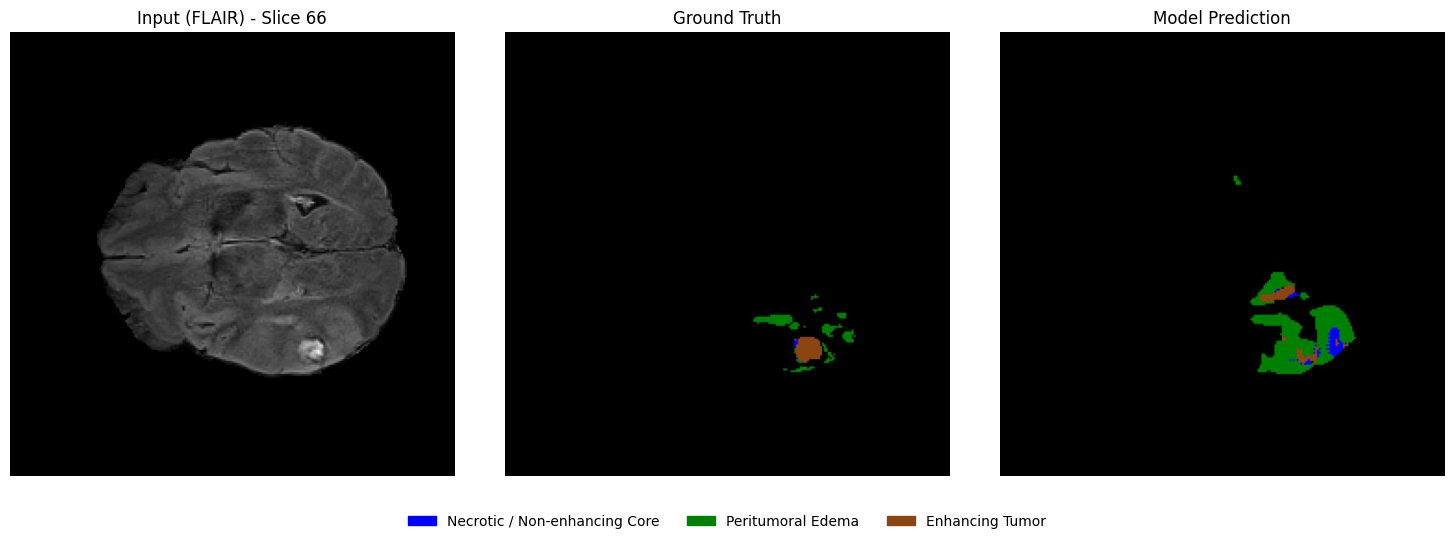

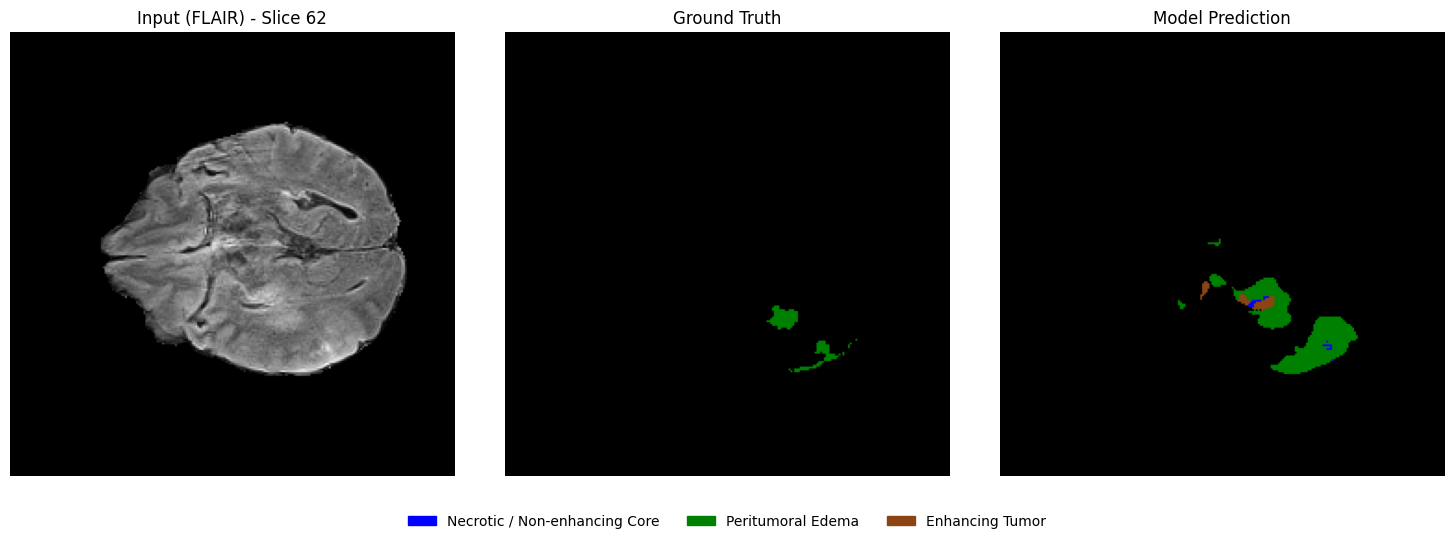

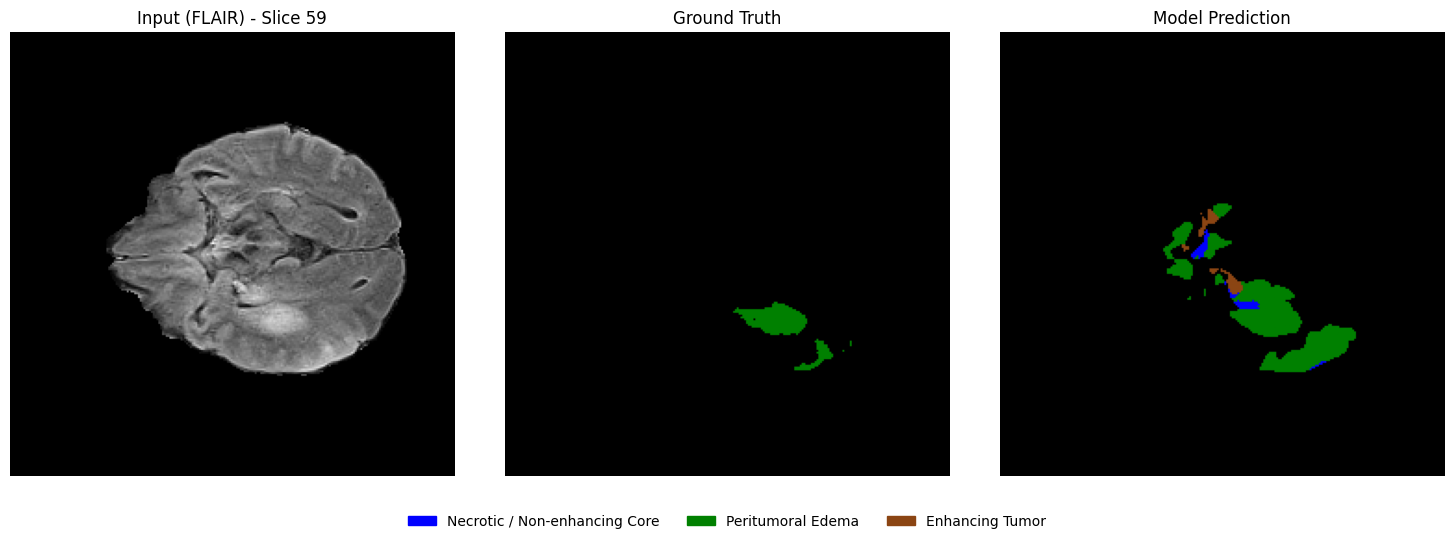

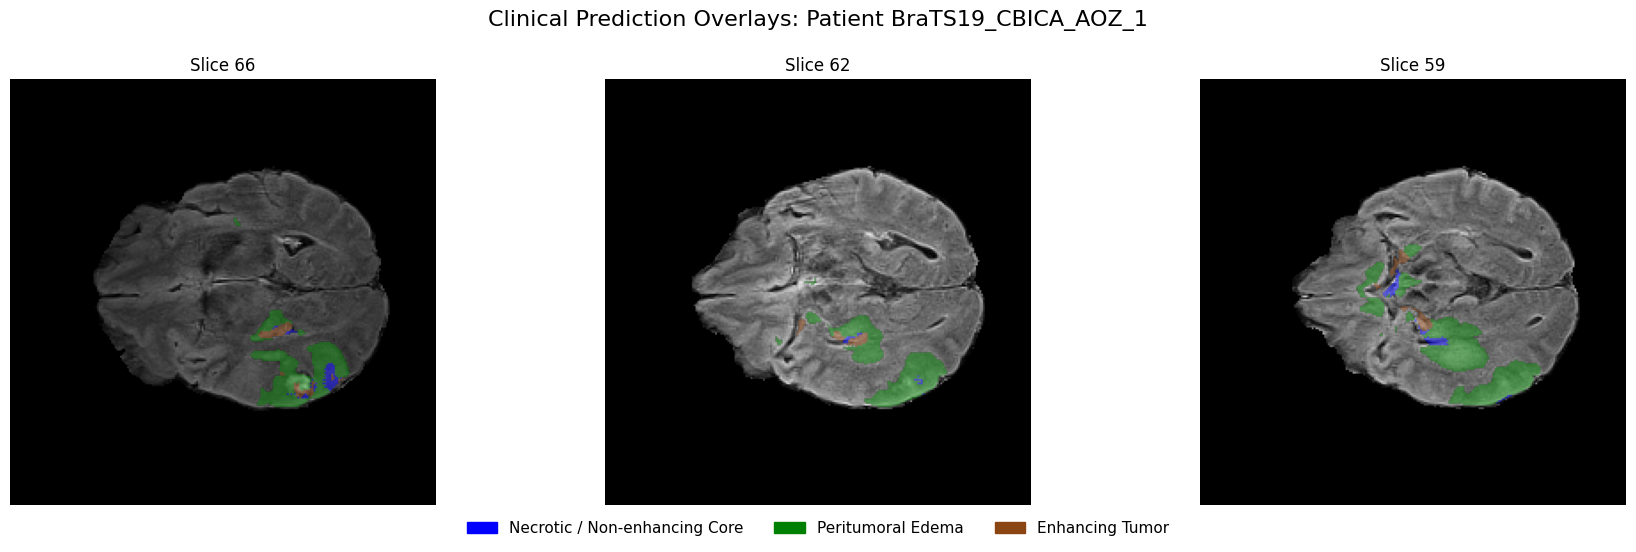

In [159]:
# 1. Define the Consistent EDA-style Colormap (Matches Overlay)
# 0: Black, 1: Blue (NCR), 2: Green (ED), 3: Brown (ET)
eda_consistent_colors = ['black', 'blue', 'green', 'saddlebrown']
my_cmap = ListedColormap(eda_consistent_colors)

# 2. Create the legend patches to match EDA descriptions
legend_labels = {
    "Necrotic / Non-enhancing Core": "blue",
    "Peritumoral Edema": "green",
    "Enhancing Tumor": "saddlebrown"
}
patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]

# 3. Visualization loop
for z in selected_slices:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # --- Panel 1: Input FLAIR ---
    axes[0].imshow(flair[:, :, z], cmap="gray")
    axes[0].set_title(f"Input (FLAIR) - Slice {z}")
    axes[0].axis("off")

    # --- Panel 2: Ground Truth ---
    # vmin/vmax ensures 0=black, 1=blue, 2=green, 3=brown
    axes[1].imshow(seg[:, :, z], cmap=my_cmap, vmin=0, vmax=3)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # --- Panel 3: Model Prediction ---
    axes[2].imshow(predictions[:, :, z], cmap=my_cmap, vmin=0, vmax=3)
    axes[2].set_title("Model Prediction")
    axes[2].axis("off")

    # --- Unified Legend (Centered at bottom of the row) ---
    fig.legend(
        handles=patches,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=3,
        fontsize=10,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

# 1. Define the EDA-consistent colors
# Blue: Necrotic / Non-enhancing Core (1), Green: Edema (2), Brown: Enhancing (3)
legend_patches = [
    mpatches.Patch(color="blue", label="Necrotic / Non-enhancing Core"),
    mpatches.Patch(color="green", label="Peritumoral Edema"),
    mpatches.Patch(color="saddlebrown", label="Enhancing Tumor"),
]
overlay_cmap = ListedColormap(["blue", "green", "saddlebrown"])

# 2. Setup the horizontal figure (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, z in enumerate(selected_slices):
    # --- Step 1: Plot the Grayscale MRI Base ---
    axes[i].imshow(flair[:, :, z], cmap="gray")

    # --- Step 2: Create a Masked Prediction Volume ---
    # Masking 0s ensures the background remains grayscale FLAIR
    pred_slice = predictions[:, :, z]
    masked_preds = np.ma.masked_where(pred_slice == 0, pred_slice)

    # --- Step 3: Overlay with Alpha for Transparency ---
    # vmin=1, vmax=3 maps the labels to our blue-green-brown list
    axes[i].imshow(masked_preds, cmap=overlay_cmap, alpha=0.5, vmin=1, vmax=3)

    axes[i].set_title(f"Slice {z}", fontsize=12)
    axes[i].axis("off")

# --- Step 4: Unified Legend for the entire Row ---
fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    fontsize=11,
    frameon=False
)

plt.suptitle(f"Clinical Prediction Overlays: Patient {viz_patient_id}", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.1, 1, 0.92]) # Adjust layout to fit Title and Legend
plt.show()

## 3D U-Net Model

In [160]:
class BraTS3DDataset(Dataset):
    def __init__(self, patient_data_list, patch_size=(64, 64, 64), training=True):
        """
        patient_data_list: List of tuples [(path, label), ...]
        patch_size: (D, H, W) dimensions for the sub-volume
        """
        self.samples = patient_data_list # Consistent with 2D structure
        self.patch_size = patch_size
        self.training = training

    def __len__(self):
        return len(self.samples)

    def _find_file(self, patient_path, keyword):
        """Consistent with 2D _find_file logic"""
        files = os.listdir(patient_path)
        for f in files:
            # Matches '_t1.nii' or '_t1.nii.gz' specifically
            if f.lower().endswith(f"_{keyword.lower()}.nii") or f.lower().endswith(f"_{keyword.lower()}.nii.gz"):
                return os.path.join(patient_path, f)
        raise FileNotFoundError(f"Could not find {keyword} in {patient_path}")

    def __getitem__(self, idx):
        # Unpack the tuple (consistent with 2D calling code)
        patient_path, _ = self.samples[idx]

        # 1. Load modalities
        t1 = normalize_volume(load_nifti(self._find_file(patient_path, "t1")))
        t1ce = normalize_volume(load_nifti(self._find_file(patient_path, "t1ce")))
        t2 = normalize_volume(load_nifti(self._find_file(patient_path, "t2")))
        flair = normalize_volume(load_nifti(self._find_file(patient_path, "flair")))
        seg = remap_labels(load_nifti(self._find_file(patient_path, "seg")))

        # 2. Stack sequences: (4, H, W, D)
        image = np.stack([t1, t1ce, t2, flair], axis=0)
        image = np.transpose(image, (0, 3, 1, 2))        # (4, D, H, W)

        mask = seg[np.newaxis, :, :, :] # Add channel dim for cropping logic
        mask = np.transpose(mask, (0, 3, 1, 2))        # (1, D, H, W)

        # 3. Crop to Patch
        if self.training:
            image, mask = self._random_spatial_crop(image, mask)
        else:
            image, mask = self._center_spatial_crop(image, mask)

        # Return (4, D, H, W) image and (D, H, W) mask
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask[0], dtype=torch.long)

    def _random_spatial_crop(self, img, mask):
        d, h, w = img.shape[1:]
        z = np.random.randint(0, d - self.patch_size[0] + 1)
        y = np.random.randint(0, h - self.patch_size[1] + 1)
        x = np.random.randint(0, w - self.patch_size[2] + 1)

        img_patch = img[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        mask_patch = mask[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        return img_patch, mask_patch

    def _center_spatial_crop(self, img, mask):
        d, h, w = img.shape[1:]
        z = (d - self.patch_size[0]) // 2
        y = (h - self.patch_size[1]) // 2
        x = (w - self.patch_size[2]) // 2

        img_patch = img[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        mask_patch = mask[:, z:z+self.patch_size[0], y:y+self.patch_size[1], x:x+self.patch_size[2]]
        return img_patch, mask_patch

# Initialize 3D datasets
train_dataset_3d = BraTS3DDataset(train_data, training=True)
val_dataset_3d   = BraTS3DDataset(val_data, training=False)
test_dataset_3d  = BraTS3DDataset(test_data, training=False)

batch_size_3d = 2  # Recommended for 3D patches on Colab Free T4

train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=batch_size_3d,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=batch_size_3d,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_3d = DataLoader(
    test_dataset_3d,
    batch_size=batch_size_3d,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [161]:
class DoubleConv3D(nn.Module):
    """
    (Conv3D -> BatchNorm3d -> ReLU) x 2
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4, base_filters=32):
        super().__init__()

        self.pool = nn.MaxPool3d(kernel_size=2)

        # -------- Encoder --------
        self.enc1 = DoubleConv3D(in_channels, base_filters)
        self.enc2 = DoubleConv3D(base_filters, base_filters * 2)
        self.enc3 = DoubleConv3D(base_filters * 2, base_filters * 4)

        # -------- Bottleneck --------
        self.bottleneck = DoubleConv3D(base_filters * 4, base_filters * 8)

        # -------- Decoder --------
        self.up3 = nn.ConvTranspose3d(base_filters * 8, base_filters * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv3D(base_filters * 8, base_filters * 4)

        self.up2 = nn.ConvTranspose3d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_filters * 4, base_filters * 2)

        self.up1 = nn.ConvTranspose3d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_filters * 2, base_filters)

        self.out_conv = nn.Conv3d(base_filters, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)          # (B, 32, 64, 64, 64)
        p1 = self.pool(s1)         # (B, 32, 32, 32, 32)

        s2 = self.enc2(p1)         # (B, 64, 32, 32, 32)
        p2 = self.pool(s2)         # (B, 64, 16, 16, 16)

        s3 = self.enc3(p2)         # (B, 128, 16, 16, 16)
        p3 = self.pool(s3)         # (B, 128, 8, 8, 8)

        # Bottleneck
        b = self.bottleneck(p3)    # (B, 256, 8, 8, 8)

        # Decoder
        d3 = self.up3(b)                                # (B, 128, 16, 16, 16)
        d3 = self.dec3(torch.cat([d3, s3], dim=1))      # Concatenate skip

        d2 = self.up2(d3)                                # (B, 64, 32, 32, 32)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))

        d1 = self.up1(d2)                                # (B, 32, 64, 64, 64)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))

        return self.out_conv(d1)

model_3d = UNet3D(
    in_channels=4,   # 4 MRI modalities
    num_classes=4,   # background + tumor regions
    base_filters=32  # lightweight for Colab
).to(device)

#print(model_3d)

In [162]:
class DiceCELoss3D(nn.Module):
    def __init__(self, num_classes=4, smooth=1e-6):
        super(DiceCELoss3D, self).__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        # Cross Entropy handles 5D inputs (B, C, D, H, W) automatically
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        """
        inputs:  (B, C, D, H, W) - Raw logits
        targets: (B, D, H, W)    - Class indices
        """
        # 1. Cross Entropy Loss
        ce_loss = self.ce(inputs, targets)

        # 2. Soft Dice Loss
        probs = F.softmax(inputs, dim=1)

        # Convert targets to one-hot: (B, D, H, W) -> (B, D, H, W, C)
        # Then permute to match model output: (B, C, D, H, W)
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 4, 1, 2, 3).float()
        targets_one_hot = targets_one_hot.to(inputs.device)

        # Sum over Batch (0), Depth (2), Height (3), and Width (4)
        # We keep the Channel dimension (1) to compute per-class Dice
        dims = (0, 2, 3, 4)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)

        dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)

        # Average the Dice score across all classes
        dice_loss = 1 - torch.mean(dice_score)

        # 3. Hybrid Weighting
        return 0.5 * ce_loss + 0.5 * dice_loss

# 1. Custom Loss Function
# We replace standard CE with our Hybrid Dice-CE for 3D volumes
criterion_3d = DiceCELoss3D(num_classes=4)

# 2. Learning Rate
learning_rate_3d = 1e-4

# 3. Optimizer AdamW
optimizer_3d = torch.optim.AdamW(
    model_3d.parameters(),
    lr=learning_rate_3d,
    weight_decay=1e-5
)

# 4. Epochs
num_epochs_3d = 15 # Set to 15 for the initial Colab run/testing

def train_unet_3d(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    save_path
):
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --------------------
        # Training phase
        # --------------------
        model.train()
        train_loss = 0.0

        # We use tqdm to monitor the progress of these heavy 3D batches
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, masks in pbar_train:
            images = images.to(device) # (B, 4, D, H, W)
            masks = masks.to(device)   # (B, D, H, W)

            optimizer.zero_grad()

            outputs = model(images)           # (B, 4, D, H, W)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar_train.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss /= len(train_loader)

        # --------------------
        # Validation phase
        # --------------------
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for images, masks in pbar_val:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                #pbar_val.set_postfix({"val_loss": f"{loss.item():.4f}"})

        val_loss /= len(val_loader)

        # --------------------
        # Save Best Model
        # --------------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"--> Model improved! Saved to {save_path}")

        # --------------------
        # Epoch summary
        # --------------------
        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] Summary: "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}\n"
        )

In [163]:
checkpoint_path_3d = os.path.join(tutorial_data_path, "best_model_3d.pth")

# Launch the 3D training
train_unet_3d(
    model=model_3d,
    train_loader=train_loader_3d,
    val_loader=val_loader_3d,
    criterion=criterion_3d,
    optimizer=optimizer_3d,
    num_epochs=num_epochs_3d,
    device=device,
    save_path = checkpoint_path_3d
)

Epoch 1/15 [Val]: 100%|██████████| 2/2 [00:04<00:00,  2.37s/it]


--> Model improved! Saved to /content/MICCAI_BraTS_2019_Data_Training/best_model_3d.pth

Epoch [1/15] Summary: Train Loss: 1.1756 | Val Loss: 1.1418



Epoch 2/15 [Val]: 100%|██████████| 2/2 [00:04<00:00,  2.12s/it]



Epoch [2/15] Summary: Train Loss: 1.0982 | Val Loss: 1.1622



Epoch 3/15 [Val]: 100%|██████████| 2/2 [00:02<00:00,  1.40s/it]


...

--> Model improved! Saved to /content/MICCAI_BraTS_2019_Data_Training/best_model_3d.pth

Epoch [13/15] Summary: Train Loss: 0.8985 | Val Loss: 0.8870



Epoch 14/15 [Val]: 100%|██████████| 2/2 [00:02<00:00,  1.41s/it]



Epoch [14/15] Summary: Train Loss: 0.8965 | Val Loss: 1.0525



Epoch 15/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.60s/it]


Epoch [15/15] Summary: Train Loss: 0.8694 | Val Loss: 0.9520



In [164]:
def multiclass_dice_3d(pred, target, num_classes=4, ignore_background=True):
    """
    pred, target: (D, H, W) tensors with class indices
    """
    dice_scores = {}
    classes = range(1, num_classes) if ignore_background else range(num_classes)

    for cls in classes:
        # Create binary masks for the specific class
        pred_c = (pred == cls).float()
        target_c = (target == cls).float()

        intersection = (pred_c * target_c).sum()
        denominator = pred_c.sum() + target_c.sum()

        if denominator == 0:
            dice = torch.tensor(float('nan'))
        else:
            dice = (2.0 * intersection) / (denominator + 1e-6)

        dice_scores[cls] = dice.item()

    return dice_scores

def evaluate_3d_model(model, dataloader, device, num_classes=4):
    model.eval()

    # Store scores: {class_id: [list_of_scores]}
    dice_accumulator = {cls: [] for cls in range(1, num_classes)}

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device) # (B, 4, D, H, W)
            masks = masks.to(device)   # (B, D, H, W)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1) # (B, D, H, W)

            for b in range(preds.size(0)):
                # Compute dice for each 3D patch in the batch
                scores = multiclass_dice_3d(
                    preds[b],
                    masks[b],
                    num_classes=num_classes
                )

                for cls, score in scores.items():
                    dice_accumulator[cls].append(score)

    # Calculate means
    #mean_dice_per_class = {
    #    cls: np.mean(val) if len(val) > 0 else 0.0
    #    for cls, val in dice_accumulator.items()
    #}

    mean_dice_per_class = {}
    for cls, scores in dice_accumulator.items():
        # Filter out NaN values (patches where the class was absent)
        valid_scores = [s for s in scores if not np.isnan(s)]

        if len(valid_scores) > 0:
            mean_dice_per_class[cls] = sum(valid_scores) / len(valid_scores)
        else:
            mean_dice_per_class[cls] = 0.0

    overall_mean_dice = np.mean(list(mean_dice_per_class.values()))

    return mean_dice_per_class, overall_mean_dice



mean_dice_3d, overall_dice_3d = evaluate_3d_model(
    model=model_3d,
    dataloader=test_loader_3d,
    device=device
)

# Clinical mapping consistent with 2D section
brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

print("3D Patch-wise Dice Score (excluding background):")
for cls, score in mean_dice_3d.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall 3D Mean Dice: {overall_dice_3d:.4f}")


def sliding_window_inference_3d(model, volume, device, patch_size=(64, 64, 64), overlap=0.5):
    """
    Reconstructs a full 3D volume prediction from patches.
    volume: (4, D, H, W)
    """
    model.eval()
    volume = volume.to(device)

    c, d, h, w = volume.shape
    num_classes = 4

    # Initialize accumulation buffers
    output_sum = torch.zeros((num_classes, d, h, w), device=device)
    count_map = torch.zeros((1, d, h, w), device=device)

    # Safe stride computation
    stride = [max(1, int(p * (1 - overlap))) for p in patch_size]

    # Helper function to ensure full coverage
    def get_positions(size, patch, stride):
        positions = list(range(0, size - patch + 1, stride))
        if positions[-1] != size - patch:
            positions.append(size - patch)
        return positions

    z_list = get_positions(d, patch_size[0], stride[0])
    y_list = get_positions(h, patch_size[1], stride[1])
    x_list = get_positions(w, patch_size[2], stride[2])

    with torch.no_grad():
        for z in z_list:
            for y in y_list:
                for x in x_list:

                    # 1. Extract patch
                    patch = volume[:,
                                   z:z+patch_size[0],
                                   y:y+patch_size[1],
                                   x:x+patch_size[2]]

                    patch = patch.unsqueeze(0)  # (1, 4, D, H, W)

                    # 2. Predict
                    output = model(patch)
                    output = torch.softmax(output, dim=1)

                    # 3. Accumulate
                    output_sum[:,
                               z:z+patch_size[0],
                               y:y+patch_size[1],
                               x:x+patch_size[2]] += output.squeeze(0)

                    count_map[:,
                              z:z+patch_size[0],
                              y:y+patch_size[1],
                              x:x+patch_size[2]] += 1

    # Normalize overlapping regions
    final_probs = output_sum / count_map

    return torch.argmax(final_probs, dim=0).cpu().numpy()  # (D, H, W)

def evaluate_full_volumes_3d(model, patient_data_list, device, patch_size=(64, 64, 64)):
    """
    patient_data_list: List of tuples [(path, label), ...]
    """
    model.eval()
    dice_accumulator = {cls: [] for cls in range(1, 4)}

    # We can use the _find_file logic from the dataset class
    temp_ds = BraTS3DDataset(patient_data_list)

    for patient_path, _ in tqdm(patient_data_list, desc="Full Volume Inference"):
        # Load modalities using the consistent _find_file logic
        t1 = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "t1")))
        t1ce = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "t1ce")))
        t2 = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "t2")))
        flair = normalize_volume(load_nifti(temp_ds._find_file(patient_path, "flair")))
        seg = remap_labels(load_nifti(temp_ds._find_file(patient_path, "seg")))

        #full_volume_tensor = torch.tensor(np.stack([t1, t1ce, t2, flair], axis=0), dtype=torch.float32)
        full_volume = np.stack([t1, t1ce, t2, flair], axis=0)  # (4, H, W, D)

        full_volume = np.transpose(full_volume, (0, 3, 1, 2))  # Convert to (4, D, H, W)
        full_volume_tensor = torch.tensor(full_volume, dtype=torch.float32)

        seg = np.transpose(seg, (2, 0, 1))  # (D, H, W)

        # Run Sliding Window
        pred_3d = sliding_window_inference_3d(model, full_volume_tensor, device, patch_size=patch_size)

        # Compute Volume-wise Dice per class
        for cls in range(1, 4):
            p_c = (pred_3d == cls).astype(np.float32)
            t_c = (seg == cls).astype(np.float32)

            intersection = np.sum(p_c * t_c)
            denominator = np.sum(p_c) + np.sum(t_c)

            if denominator == 0:
                dice = np.nan # Consistent with 2D and 3D-patch logic
            else:
                dice = (2.0 * intersection) / (denominator + 1e-6)

            dice_accumulator[cls].append(dice)

    # Calculate means with NaN filtering
    mean_dice_per_class = {}
    for cls, scores in dice_accumulator.items():
        valid_scores = [s for s in scores if not np.isnan(s)]
        mean_dice_per_class[cls] = np.mean(valid_scores) if valid_scores else 0.0

    overall_mean_dice = np.mean(list(mean_dice_per_class.values()))

    return mean_dice_per_class, overall_mean_dice

3D Patch-wise Dice Score (excluding background):
  Necrotic / Non-enhancing Core (NCR/NET): 0.0095
  Edema (ED): 0.5870
  Enhancing Tumor (ET): 0.1655

Overall 3D Mean Dice: 0.2540


In [165]:
# Use the same test_data list of tuples
mean_dice_vol, overall_dice_vol = evaluate_full_volumes_3d(
    model=model_3d,
    patient_data_list=test_data,
    device=device
)

brats_classes = {
    1: "Necrotic / Non-enhancing Core (NCR/NET)",
    2: "Edema (ED)",
    3: "Enhancing Tumor (ET)" # This is the remapped Label 4
}

print("3D Full-Volume Dice Score Summary:")
for cls, score in mean_dice_vol.items():
    name = brats_classes.get(cls, f"Class {cls}")
    print(f"  {name}: {score:.4f}")

print(f"\nOverall 3D Full-Volume Mean Dice: {overall_dice_vol:.4f}")

Full Volume Inference: 100%|██████████| 4/4 [00:42<00:00, 10.60s/it]

3D Full-Volume Dice Score Summary:
  Necrotic / Non-enhancing Core (NCR/NET): 0.0028
  Edema (ED): 0.2676
  Enhancing Tumor (ET): 0.0164

Overall 3D Full-Volume Mean Dice: 0.0956


In [166]:
# 1. Randomly select a patient
test_patient_paths = [item[0] for item in test_data]
viz_patient_dir = random.choice(test_patient_paths)
print(f"Visualizing Patient: {os.path.basename(viz_patient_dir)}")

# 2. Load & Normalize (Using your established logic)
t1 = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "t1")))
t1ce = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "t1ce")))
t2 = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "t2")))
flair = normalize_volume(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "flair")))
seg_gt = remap_labels(load_nifti(BraTS3DDataset._find_file(None, viz_patient_dir, "seg")))

full_volume = np.stack([t1, t1ce, t2, flair], axis=0)  # (4, H, W, D)
full_volume = np.transpose(full_volume, (0, 3, 1, 2))  # (4, D, H, W)

full_volume_tensor = torch.tensor(full_volume, dtype=torch.float32)

seg_gt = np.transpose(seg_gt, (2, 0, 1))  # (D, H, W)

# 3. Run 3D Sliding Window Inference
# This ensures we get a full volume, not just a 64x64x64 patch
pred_volume = sliding_window_inference_3d(model_3d, full_volume_tensor, device=device, patch_size=(64, 64, 64))

print(f"Full Volume Prediction complete. Shape: {pred_volume.shape}")

# Find the slice index with the most tumor pixels
tumor_mask = (seg_gt > 0)
#z_counts = np.sum(tumor_mask, axis=(0, 1))

# Sum across Height (1) and Width (2) to get counts for each Slice (0)
z_counts = np.sum(tumor_mask, axis=(1, 2))
best_z = np.argmax(z_counts)

# Identify a random selection of tumor-heavy slices for variety
tumor_slices = np.where(z_counts > (np.max(z_counts) * 0.5))[0]

# Use min() to avoid the "Sample larger than population" error
num_to_sample = min(len(tumor_slices), 3)

if num_to_sample > 0:
    selected_slices = random.sample(list(tumor_slices), num_to_sample)
else:
    # Fallback: just use the best_z if no other good slices exist
    selected_slices = [best_z]

#selected_slices = random.sample(list(tumor_slices), 3)

Visualizing Patient: BraTS19_CBICA_ATN_1
Full Volume Prediction complete. Shape: (155, 240, 240)


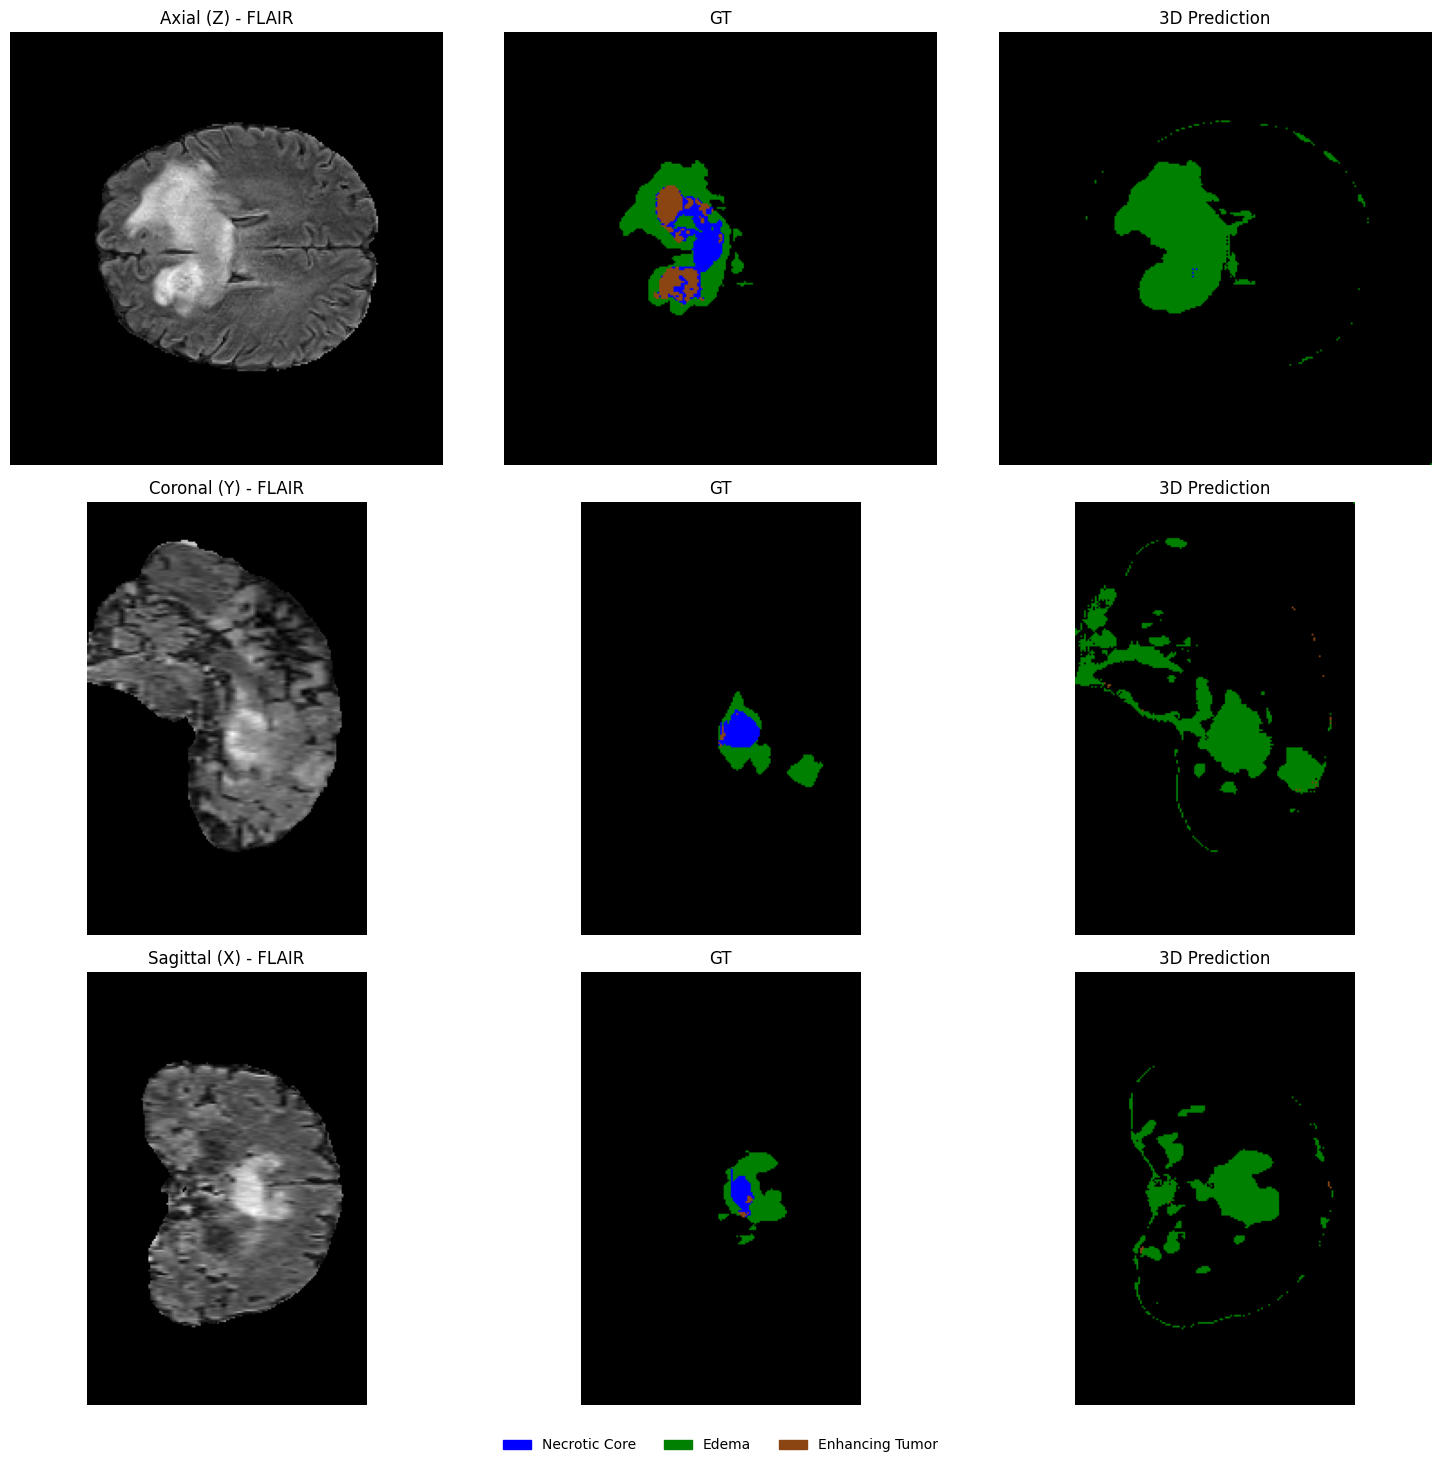

--- Clinical Overlays: Patient BraTS19_CBICA_ATN_1 ---


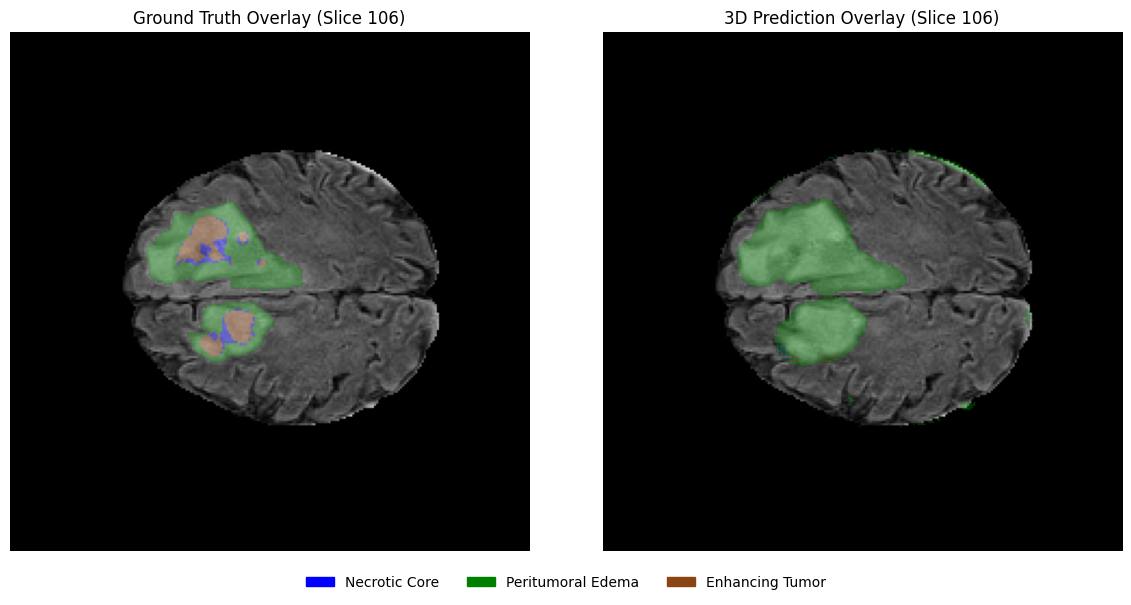

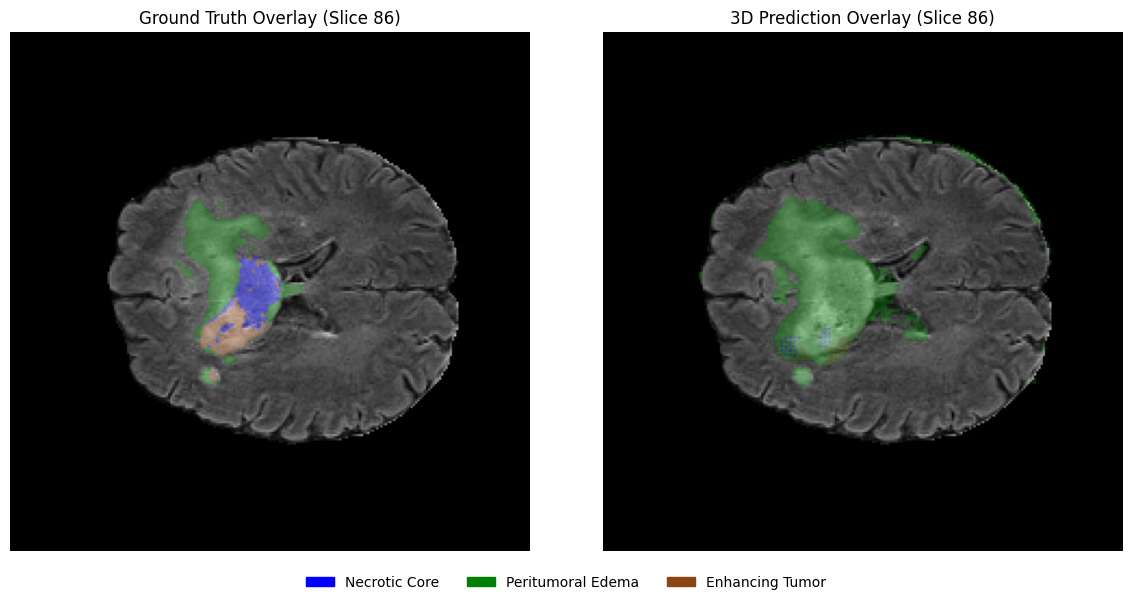

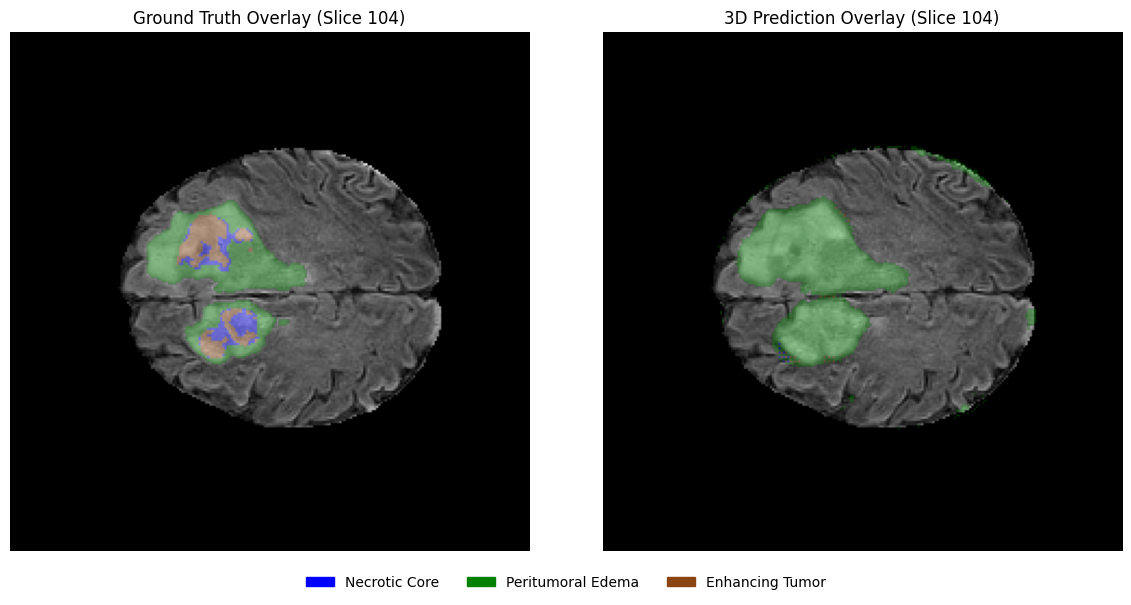

In [167]:
def plot_orthogonal_views(flair, gt, pred, slice_idx):
    """
    Visualizes axial, coronal, and sagittal planes for (D, H, W) data.
    flair: (H, W, D) -> (240, 240, 155)
    gt & pred: (D, H, W) -> (155, 240, 240)
    """
    # 0. Align flair with the others immediately
    flair = np.transpose(flair, (2, 0, 1)) # Now (155, 240, 240)

    # 1. Colors & Legend (Keep your consistent style)
    eda_consistent_colors = ['black', 'blue', 'green', 'saddlebrown']
    my_cmap = ListedColormap(eda_consistent_colors)
    legend_labels = {
        "Necrotic Core": "blue",
        "Edema": "green",
        "Enhancing Tumor": "saddlebrown"
    }
    patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]

    d, h, w = gt.shape
    mid_z, mid_y, mid_x = slice_idx, h//2, w//2

    # 2. Correct Slicing for (D, H, W)
    # Axial:   Slice along D (0), view H, W
    # Coronal: Slice along H (1), view D, W
    # Sagittal: Slice along W (2), view D, H

    # Note: We use np.rot90 to make 'Depth' the vertical axis for Coronal/Sagittal
    views = [
        (flair[mid_z, :, :], gt[mid_z, :, :], pred[mid_z, :, :], "Axial (Z)"),
        (np.rot90(flair[:, mid_y, :]), np.rot90(gt[:, mid_y, :]), np.rot90(pred[:, mid_y, :]), "Coronal (Y)"),
        (np.rot90(flair[:, :, mid_x]), np.rot90(gt[:, :, mid_x]), np.rot90(pred[:, :, mid_x]), "Sagittal (X)")
    ]

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for i, (f_v, g_v, p_v, name) in enumerate(views):
        # FLAIR
        axes[i, 0].imshow(f_v, cmap="gray")
        axes[i, 0].set_title(f"{name} - FLAIR")
        axes[i, 0].axis("off")

        # Ground Truth
        axes[i, 1].imshow(g_v, cmap=my_cmap, vmin=0, vmax=3)
        axes[i, 1].set_title(f"GT")
        axes[i, 1].axis("off")

        # Prediction
        axes[i, 2].imshow(p_v, cmap=my_cmap, vmin=0, vmax=3)
        axes[i, 2].set_title(f"3D Prediction")
        axes[i, 2].axis("off")

    fig.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

plot_orthogonal_views(flair, seg_gt, pred_volume, best_z)

def plot_3d_segmentation_overlays(flair, gt, pred, selected_slices, patient_id=""):
    """
    Plots a side-by-side comparison of GT and Prediction.
    flair: (H, W, D) -> (240, 240, 155)
    gt & pred: (D, H, W) -> (155, 240, 240)
    """
    # 0. Sync flair dimension to match gt and pred (D, H, W)
    flair = np.transpose(flair, (2, 0, 1))

    # 1. Define the EDA-consistent colors (Labels 1, 2, 3)
    legend_patches = [
        mpatches.Patch(color="blue", label="Necrotic Core"),
        mpatches.Patch(color="green", label="Peritumoral Edema"),
        mpatches.Patch(color="saddlebrown", label="Enhancing Tumor"),
    ]
    overlay_cmap = ListedColormap(["blue", "green", "saddlebrown"])

    print(f"--- Clinical Overlays: Patient {patient_id} ---")

    for z in selected_slices:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Consistent setup for both Ground Truth and Prediction
        data_to_plot = [gt, pred]
        titles = ["Ground Truth Overlay", "3D Prediction Overlay"]

        for ax, volume, title in zip(axes, data_to_plot, titles):
            # --- Step 1: Plot the Grayscale MRI Base ---
            # Using index [z, :, :] because flair is now (D, H, W)
            ax.imshow(flair[z, :, :], cmap="gray")

            # --- Step 2: Create a Masked Volume ---
            # Masking 0s ensures the background remains grayscale FLAIR
            slice_data = volume[z, :, :]
            masked_data = np.ma.masked_where(slice_data == 0, slice_data)

            # --- Step 3: Overlay with Alpha ---
            # vmin=1, vmax=3 correctly maps (1: blue, 2: green, 3: saddlebrown)
            ax.imshow(masked_data, cmap=overlay_cmap, alpha=0.4, vmin=1, vmax=3)

            ax.set_title(f"{title} (Slice {z})")
            ax.axis("off")

        # --- Step 4: Unified Legend ---
        fig.legend(
            handles=legend_patches,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.02),
            ncol=3,
            fontsize=10,
            frameon=False
        )

        plt.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()

plot_3d_segmentation_overlays(
    flair=flair,
    gt=seg_gt,
    pred=pred_volume,
    selected_slices=selected_slices,
    patient_id=os.path.basename(viz_patient_dir)
)